In [ ]:
#installation des bibliothèques
pip install pandas numpy scikit-learn imbalanced-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\U\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
#importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import tree
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter

In [3]:
#chargement du dataset
data = pd.read_csv(r"F:\Hackaton\IA-Hack2026-Groupe_8\AI4BMI_predictive_maintenance_dataset.csv")
data

,machine_id,machine_type,timestamp,maintenance_age_days,vib_mean,vib_std,vib_rms,temp_mean,temp_max,current_mean,current_peak,acoustic_energy,rpm_mean,oil_particle_count,failure_next_24h
0,CONV_03,Convoyeur,2025-01-01 00:00:00,179,3.888120,0.563780,4.116024,65.052576,67.471698,13.424491,14.853110,81.518343,1238.745099,69.007394,1
1,CONV_06,Convoyeur,2025-01-01 00:00:10,14,6.465649,0.454845,6.672402,52.876259,55.331876,15.332768,16.181774,107.513960,1439.936131,44.166125,0
2,CONV_11,Convoyeur,2025-01-01 00:00:20,171,4.466351,0.498894,4.643406,61.946745,63.681625,18.275977,23.054290,123.872794,1521.863832,67.635221,0
3,KUKA_08,Robot,2025-01-01 00:00:30,39,5.473193,0.631838,5.907268,65.354926,68.451342,16.257306,17.304279,79.042588,1312.432323,22.664357,0
4,KUKA_11,Robot,2025-01-01 00:00:40,80,5.930584,0.635553,6.200428,60.868010,64.530295,15.723366,17.555161,123.295373,1475.425231,34.606645,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,KUKA_06,Robot,2025-01-24 03:32:30,89,3.340727,0.552162,3.699601,51.577656,53.283083,19.188379,21.597904,106.100844,1345.221676,69.811095,0
199996,CONV_04,Convoyeur,2025-01-24 03:32:40,176,5.292033,0.955863,5.436693,56.046602,58.416140,14.945253,16.286795,117.079445,1443.270078,48.190428,1
199997,FANUC_08,CNC,2025-01-24 03:32:50,66,3.371230,0.408094,3.418245,60.552349,63.128722,17.739837,20.142099,123.410296,1388.506611,39.819596,1
199998,FANUC_10,CNC,2025-01-24 03:33:00,78,4.727202,0.513487,4.946240,57.932511,62.368395,15.615938,14.310520,66.901831,1506.758939,49.448320,0


In [4]:
#Random forest 


# --- 1. Préparation de votre jeu de données ---
# Remplacez cette section par le chargement de votre propre jeu de données.
# Votre jeu de données doit être sous forme de tableaux NumPy ou de DataFrames Pandas.
# X doit contenir les caractéristiques (features) et y la variable cible (target).
# Pour la classification binaire, y doit contenir des valeurs 0 et 1.


data = data

 # --- NOUVEAU : Gestion des valeurs manquantes (NaN) ---
initial_shape = data.shape
print(f"Taille initiale du dataset : {initial_shape}")

# Vérification des NaNs
nan_counts = data.isnull().sum()
if nan_counts.any():
    print("Valeurs manquantes détectées par colonne :")
    print(nan_counts[nan_counts > 0])

        # Option 1 : Supprimer les lignes avec des NaNs (recommandé pour la variable cible)
    data = data.dropna(subset=['failure_next_24h'])

        # Option 2 : Imputer ou supprimer pour les autres colonnes
        # Ici, on supprime pour garantir la propreté, mais on pourrait imputer par la moyenne
    data = data.dropna()

    print(f"Taille après suppression des NaNs : {data.shape}")
    print(f"Nombre de lignes supprimées : {initial_shape[0] - data.shape[0]}")


le = LabelEncoder()
data['machine_type_encoded'] = le.fit_transform(data['machine_type'])

X = data[['maintenance_age_days', 'vib_mean', 'vib_std', 'vib_rms',
        'temp_mean', 'temp_max', 'current_mean', 'current_peak',
        'acoustic_energy', 'rpm_mean', 'oil_particle_count', 'machine_type_encoded']].values

y = data['failure_next_24h'].values 



print(f"Forme de X (caractéristiques): {X.shape}")
print(f"Forme de y (cible): {y.shape}")
print(f"Classes uniques dans y: {np.unique(y)}") # Devrait afficher [0 1] pour binaire



# Vérifiez la distribution des classes
print(f"Distribution des classes avant SMOTE: {Counter(y)}")

# Division du jeu de données en ensembles d'entraînement et de test ---
# Il est crucial de diviser vos données pour évaluer la performance du modèle sur des données non vues.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {len(X_train)} échantillons")
print(f"Taille de l'ensemble de test: {len(X_test)} échantillons")

#Définition et entraînement du pipeline (SMOTE + RandomForest) ---
# Nom du fichier pour sauvegarder le modèle
model_filename = 'random_forest_smote_pipeline.joblib'

# Initialisation et entraînement du modèle RandomForestClassifier de scikit-learn ---
# Vous pouvez ajuster les hyperparamètres ici. Voici quelques-uns des plus courants:
# n_estimators: Le nombre d'arbres dans la forêt.
# max_depth: La profondeur maximale de chaque arbre.
# min_samples_split: Le nombre minimum d'échantillons requis pour diviser un nœud interne.
# min_samples_leaf: Le nombre minimum d'échantillons requis pour être à un nœud feuille.
# random_state: Pour la reproductibilité des résultats.
# class_weight: Pour gérer les déséquilibres de classes (ex: 'balanced', 'balanced_subsample').

# Vérifier si le modèle existe déjà pour éviter de le réentraîner inutilement
if os.path.exists(model_filename):
    print(f"\nChargement du modèle existant depuis {model_filename}...")
    pipeline = joblib.load(model_filename)
    print("Modèle chargé avec succès.")
else:
    print("\nEntraînement d'un nouveau modèle (SMOTE + RandomForest)...")
    sm = SMOTE(random_state=42)
    rf_classifier = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    )
    pipeline = Pipeline([
        ('smote', sm),
        ('randomforest', rf_classifier)
    ])
    pipeline.fit(X_train, y_train)
    print("Pipeline entraîné.")

    # --- 4. Sauvegarde du modèle entraîné ---
    print(f"Sauvegarde du modèle entraîné dans {model_filename}...")
    joblib.dump(pipeline, model_filename)
    print("Modèle sauvegardé avec succès.")



# Afficher la distribution des classes après SMOTE (sur l'ensemble d'entraînement)
# Note: Pour voir la distribution exacte après SMOTE, vous devriez appliquer SMOTE séparément
# et ensuite entraîner le modèle. Le pipeline le fait en interne.
# X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
# print(f"Distribution des classes dans l'ensemble d'entraînement après SMOTE: {Counter(y_resampled)}")

# --- 4. Faire des prédictions sur l'ensemble de test ---
# Le pipeline gère automatiquement l'application du modèle entraîné sur les données de test.
print("\nFaire des prédictions sur l'ensemble de test...")
y_pred = pipeline.predict(X_test)

# Vous pouvez également obtenir les probabilités de prédiction pour chaque classe
y_pred_proba = pipeline.predict_proba(X_test)
print(f"Exemple de probabilités de prédiction (premiers 5 échantillons):\n{y_pred_proba[:5]}")

# --- 5. Évaluation de la performance du modèle ---
# Pour la classification binaire, plusieurs métriques sont importantes.

accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrécision (Accuracy) du modèle Random Forest: {accuracy:.4f}")

print("\nRapport de Classification:\n")
print(classification_report(y_test, y_pred))

Taille initiale du dataset : (200000, 15)
Forme de X (caractéristiques): (200000, 12)
Forme de y (cible): (200000,)
Classes uniques dans y: [0 1]
Distribution des classes avant SMOTE: Counter({0: 164204, 1: 35796})
Taille de l'ensemble d'entraînement: 160000 échantillons
Taille de l'ensemble de test: 40000 échantillons

Chargement du modèle existant depuis random_forest_smote_pipeline.joblib...
Modèle chargé avec succès.

Faire des prédictions sur l'ensemble de test...
Exemple de probabilités de prédiction (premiers 5 échantillons):
[[0.37287495 0.62712505]
 [0.71397704 0.28602296]
 [0.66670491 0.33329509]
 [0.88477355 0.11522645]
 [0.60908443 0.39091557]]

Précision (Accuracy) du modèle Random Forest: 0.6697

Rapport de Classification:

              precision    recall  f1-score   support

           0       0.87      0.71      0.78     32841
           1       0.27      0.50      0.35      7159

    accuracy                           0.67     40000
   macro avg       0.57      0.60 

Modèle sauvegardé: models\random_forest_smote_pipeline.joblib
Metadata saved: models\randomforest_balanced_metadata.json


,precision,recall,f1,support
class,,,,
0,0.867043,0.705916,0.778227,32841.0
1,0.271754,0.503422,0.352970,7159.0


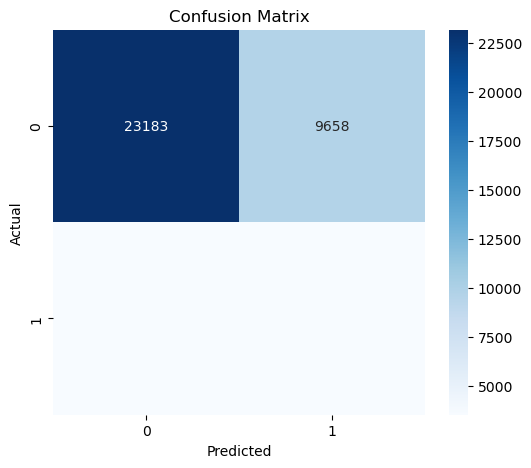

In [6]:
# --- 6. Sauvegarde finale, métadonnées et évaluation par classe ---
# Crée le dossier models/ si nécessaire et sauvegarde le pipeline entraîné dedans
import os
os.makedirs('models', exist_ok=True)
model_path = os.path.join('models', 'random_forest_smote_pipeline.joblib')
joblib.dump(pipeline, model_path)
print(f"Modèle sauvegardé: {model_path}")

# Génère un fichier JSON de métadonnées détaillant le modèle et ses métriques par classe
from datetime import datetime
import json
from sklearn.metrics import precision_recall_fscore_support

precisions, recalls, f1s, supports = precision_recall_fscore_support(y_test, y_pred, labels=np.unique(y), zero_division=0)
classes = np.unique(y_test)
metadata = {
    "model_name": "random_forest_smote_pipeline",
    "saved_at": datetime.utcnow().isoformat() + "Z",
    "model_path": model_path,
    "n_estimators": pipeline.named_steps['randomforest'].n_estimators if 'randomforest' in pipeline.named_steps else None,
    "max_depth": pipeline.named_steps['randomforest'].max_depth if 'randomforest' in pipeline.named_steps else None,
    "class_weight": str(pipeline.named_steps['randomforest'].class_weight) if 'randomforest' in pipeline.named_steps else None,
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "class_distribution_train": {str(k): int(v) for k, v in Counter(y_train).items()},
    "class_distribution_test": {str(k): int(v) for k, v in Counter(y_test).items()},
    "accuracy": float(accuracy),
    "per_class_metrics": {}
}
for cls, p, r, f, s in zip(classes, precisions, recalls, f1s, supports):
    metadata['per_class_metrics'][str(int(cls))] = {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}

meta_path = os.path.join('models','randomforest_balanced_metadata.json')
with open(meta_path,'w', encoding='utf-8') as mf:
    json.dump(metadata, mf, indent=4, ensure_ascii=False)
print(f"Metadata saved: {meta_path}")

# Affiche les métriques par classe sous forme de DataFrame
import pandas as pd
df_metrics = pd.DataFrame(metadata['per_class_metrics']).T
df_metrics.index.name = 'class'
display(df_metrics)

# Matrice de confusion (heatmap)
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()